# Lab 9: Decision Trees & Random Forests – Loan Data

In this lab, I will be working with real lending data from LendingClub.com to predict whether a borrower will fully pay back their loan. I'll train and compare two models: a Decision Tree and a Random Forest.

Here's a quick overview of what each column means:

* credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
* purpose: The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
* int.rate: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
* installment: The monthly installments owed by the borrower if the loan is funded.
* log.annual.inc: The natural log of the self-reported annual income of the borrower.
* dti: The debt-to-income ratio of the borrower (amount of debt divided by annual income).
* fico: The FICO credit score of the borrower.
* days.with.cr.line: The number of days the borrower has had a credit line.
* revol.bal: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).
* revol.util: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
* inq.last.6mths: The borrower's number of inquiries by creditors in the last 6 months.
* delinq.2yrs: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.
* pub.rec: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Load the Data

In [3]:
loans = pd.read_csv('loan_data.csv')

In [4]:
loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [5]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [6]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


The dataset has 9,578 rows and 14 columns. I noticed that the target variable not.fully.paid is imbalanced. Most borrowers (8,045) paid in full, while only 1,533 did not. The purpose column is the only categorical one, so I'll need to handle it before modeling.

## 3. Exploratory Data Analysis (EDA)

### FICO Score Distribution by Credit Policy

I plotted two histograms of FICO scores on top of each other — one for borrowers who meet the credit policy and one for those who don't.

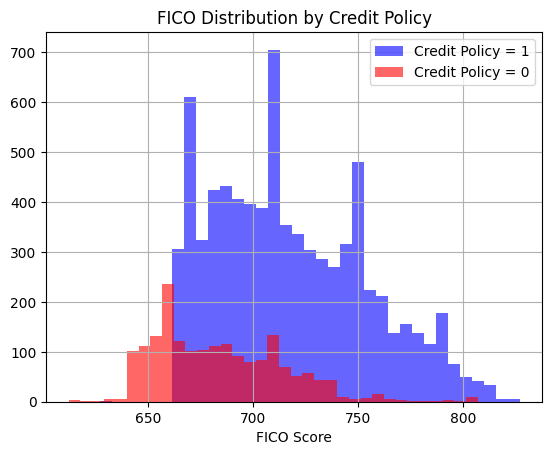

In [7]:
loans[loans['credit.policy'] == 1]['fico'].hist(bins=35, color='blue', label='Credit Policy = 1', alpha=0.6)
loans[loans['credit.policy'] == 0]['fico'].hist(bins=35, color='red', label='Credit Policy = 0', alpha=0.6)
plt.legend()
plt.xlabel('FICO Score')
plt.title('FICO Distribution by Credit Policy')
plt.show()

Borrowers who meet the credit policy tend to have higher FICO scores, which makes sense since LendingClub uses stricter criteria when approving loans.

### FICO Score Distribution by Repayment Status

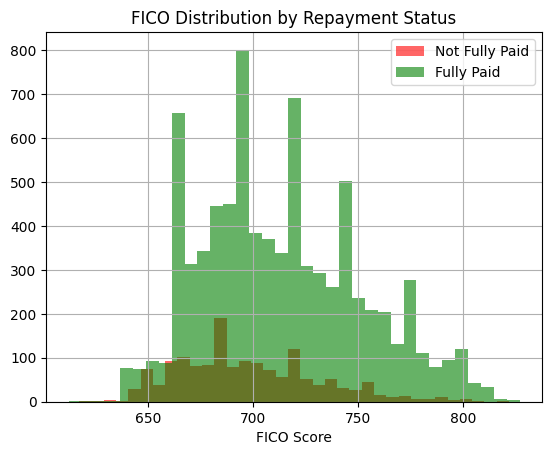

In [8]:
loans[loans['not.fully.paid'] == 1]['fico'].hist(bins=35, color='red', label='Not Fully Paid', alpha=0.6)
loans[loans['not.fully.paid'] == 0]['fico'].hist(bins=35, color='green', label='Fully Paid', alpha=0.6)
plt.legend()
plt.xlabel('FICO Score')
plt.title('FICO Distribution by Repayment Status')
plt.show()

Borrowers who didn't fully pay their loans tend to have lower FICO scores, so this feature should be useful for the model.

### Loan Count by Purpose

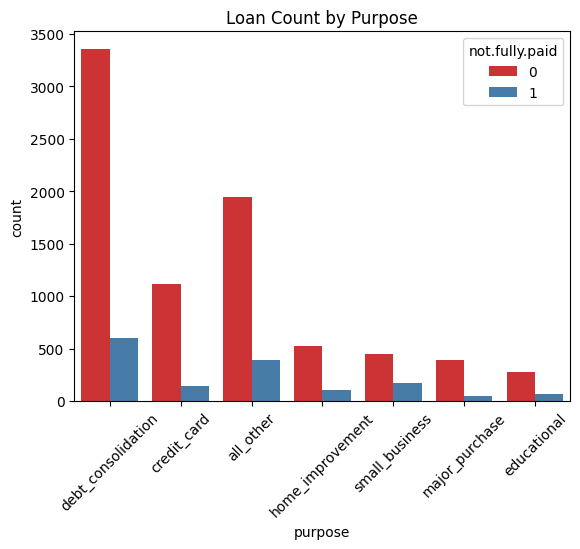

In [9]:
sns.countplot(x='purpose', data=loans, hue='not.fully.paid', palette='Set1')
plt.xticks(rotation=45)
plt.title('Loan Count by Purpose')
plt.show()

Debt consolidation is the most common loan purpose by far. Small business loans seem to have a higher proportion of defaults compared to other categories.

### FICO Score vs Interest Rate

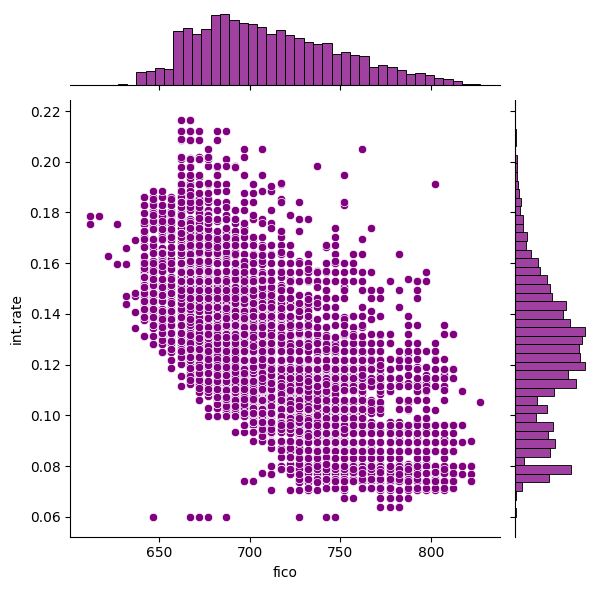

In [10]:
sns.jointplot(x='fico', y='int.rate', data=loans, color='purple')
plt.show()

There's a clear negative relationship here — the higher the FICO score, the lower the interest rate assigned. This aligns with how LendingClub prices loans based on risk.

### Interest Rate Trend by Credit Policy and Repayment Status

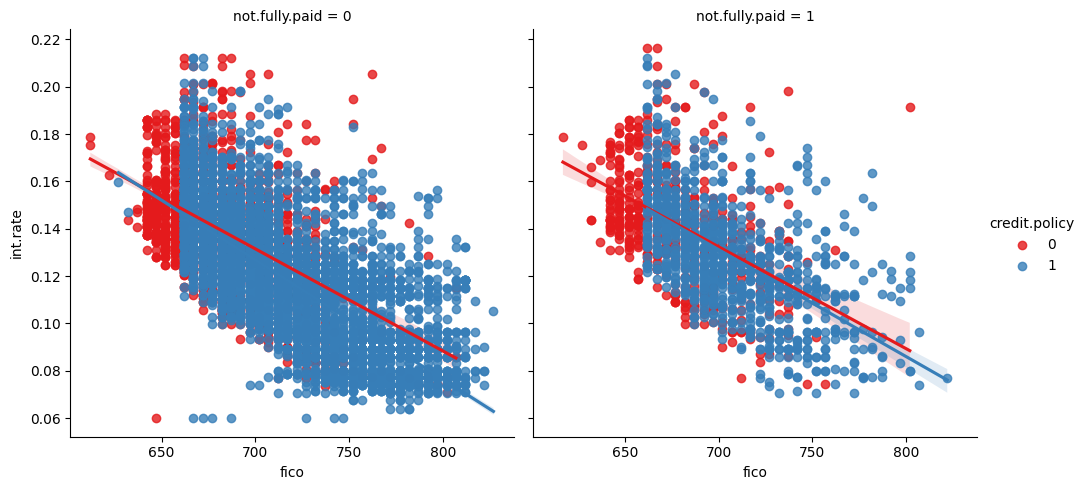

In [11]:
sns.lmplot(x='fico', y='int.rate', data=loans,
           hue='credit.policy', col='not.fully.paid', palette='Set1')
plt.show()

The negative trend between FICO and interest rate holds across all groups. Borrowers who didn't fully pay tend to have higher interest rates and lower FICO scores regardless of credit policy.

## 4. Setting Up the Data

### Handling Categorical Features

The purpose column is categorical, so I need to convert it to dummy variables before using it in sklearn.

In [12]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [13]:
cat_feats = ['purpose']

In [14]:
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)
final_data.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,True,False,False,False,False,False


After encoding, the purpose column was replaced by 6 binary dummy columns. Now all features are numeric and ready for modeling.

## 5. Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

## 6. Decision Tree Model

I'll start with a single Decision Tree as a baseline before moving on to the Random Forest.

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

### Predictions and Evaluation

In [19]:
pred_dt = dtree.predict(X_test)

Confusion Matrix:

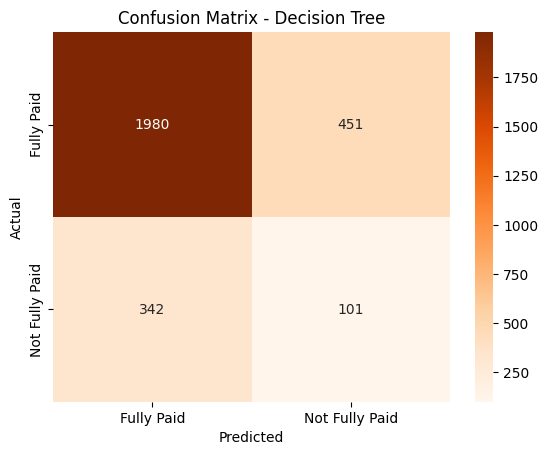

In [20]:
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_test, pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fully Paid', 'Not Fully Paid'],
            yticklabels=['Fully Paid', 'Not Fully Paid'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Classification Report:

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2431
           1       0.18      0.23      0.20       443

    accuracy                           0.72      2874
   macro avg       0.52      0.52      0.52      2874
weighted avg       0.75      0.72      0.74      2874



The Decision Tree got 73% accuracy overall. It struggled a bit with Class 1 (not fully paid), which makes sense given how few samples there are for that class.

## 7. Random Forest Model

Now I'll train a Random Forest, which builds many decision trees and averages their results. This usually reduces overfitting compared to a single tree.

In [22]:
from sklearn.ensemble import RandomForestClassifier

In [23]:
rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=600)

### Predictions and Evaluation

In [24]:
pred_rfc = rfc.predict(X_test)

Classification Report:

In [25]:
print(classification_report(y_test, pred_rfc))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.64      0.02      0.04       443

    accuracy                           0.85      2874
   macro avg       0.75      0.51      0.48      2874
weighted avg       0.82      0.85      0.78      2874



Confusion Matrix:

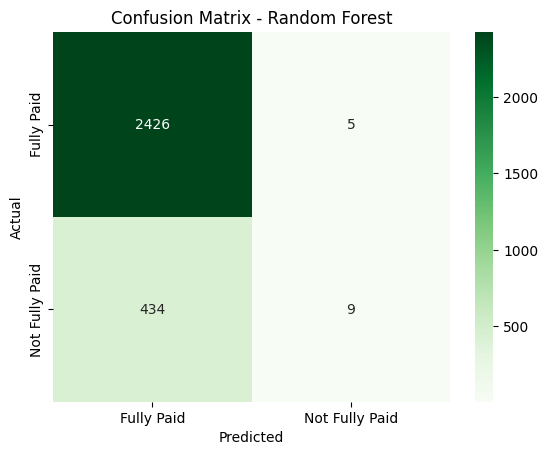

In [26]:
cm_rfc = confusion_matrix(y_test, pred_rfc)

sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fully Paid', 'Not Fully Paid'],
            yticklabels=['Fully Paid', 'Not Fully Paid'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

The Random Forest got 85% overall accuracy, which is higher than the Decision Tree. However, because the dataset is imbalanced, it mostly predicted Class 0. It almost completely missed the defaulters.

## 8. Which Model Performed Better?

| Metric | Decision Tree | Random Forest |
|---|---|---|
| Overall Accuracy | 73% | 85% |
| Class 0 Precision | 86% | 85% |
| Class 1 Recall | 24% | 2% |
| Class 1 F1-Score | 22% | 5% |

The Random Forest had better overall accuracy, but the Decision Tree was actually more useful for detecting defaulters (Class 1). In a loan prediction scenario, missing a defaulter is more costly than a false alarm, so recall for Class 1 matters a lot. That said, both models are affected by the class imbalance in the data, and something like oversampling could help improve results.